### 📁 Mount Google Drive & Extract Dataset
### 📁 ربط جوجل دريف وفك ضغط ملف الـ Dataset

> **English:** Mount Google Drive to access project files, locate the compressed archive, and extract the dataset to the local Colab directory.

> **العربية:** ربط جوجل دريف للوصول لملفات المشروع، تحديد مسار الأرشيف المضغوط، وفك ضغط ملف الـ Dataset داخل بيئة العمل.

In [1]:
from google.colab import drive # استيراد مكتبة الدرايف | Import Drive library
import zipfile # مكتبة التعامل مع الملفات المضغوطة | ZIP file library
import os # مكتبة أوامر النظام والمجلدات | OS library for directories

# ربط الحساب بالدرايف للوصول للملفات | Mount Google Drive to access files
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
# مسار ملفك المضغوط ومكان فكه | Path of ZIP file and extraction destination
zip_path = '/content/drive/MyDrive/archive_2.zip'
extract_path = '/content/dataset'

# عملية فك الضغط فعلياً | Execute extraction process
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)



### 📂 Dataset Loading & Initial Inspection
### 📂 تحميل واستعراض بيانات المشروع الأولية

> **English:** List directory contents, load the large dataset CSV file with proper column naming and encoding, and inspect the first few rows.

> **العربية:** استعراض محتويات المجلد، تحميل ملف الـ Dataset مع تسمية الأعمدة وتحديد الـ Encoding المناسب، وعرض عينة من البيانات.

In [3]:
import os
os.listdir("/content/dataset")

['training.1600000.processed.noemoticon.csv']

In [4]:
import pandas as pd
fill_path="/content/dataset/training.1600000.processed.noemoticon.csv"

coulumn_names=["target","ids","data","flag","user","text"]

df=pd.read_csv(fill_path,encoding="ISO-8859-1",header=None,names=coulumn_names)
df.head()


,target,ids,data,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


### 🧹 Advanced Text Cleansing & Normalization
### 🧹 التنظيف المتقدم للنصوص ومعالجتها

> **English:** Implement advanced text cleaning functions including lowercasing, URL/mention/hashtag removal, elongation handling, and stopword filtering while preserving vital negation terms.

> **العربية:** تطبيق دالة تنظيف متقدمة تشمل توحيد الحروف (Lowercasing)، إزالة الروابط والمنشن والهاشتاج، معالجة الحروف المكررة، وفلترة كلمات الوقف مع الحفاظ على كلمات النفي الهامة.

In [8]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [9]:
import re
from nltk.corpus import stopwords

# تحميل كلمات الوقف واستثناء كلمات النفي منها
stop_words = set(stopwords.words('english'))
negation_words = {'not', 'no', 'never', 'neither', 'nor', 'but'}
final_stopwords = stop_words - negation_words

def advanced_normalization(text):
    # 1. توحيد الحالة (Lowercasing)
    text = text.lower()

    # 2. حذف الروابط والمنشن والهاشتاج
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # الروابط
    text = re.sub(r'@\w+', '', text)                 # المنشن
    text = re.sub(r'#', '', text)                    # علامة الهاشتاج بس

    # 3. التعامل مع الحروف المتكررة (Lengthening)
    # بنخلي looooove -> love (حرفين بس كفاية للموديل)
    text = re.sub(r'(.)\1+', r'\1\1', text)

    # 4. تنظيف الرموز الغريبة مع الحفاظ على علامات الترقيم المهمة (اختياري)
    # لو عاوز تشيل كل حاجة ما عدا الحروف سيب السطر اللي تحت
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 5. حذف الـ Stopwords (النسخة الذكية)
    text = " ".join([word for word in text.split() if word not in final_stopwords])

    # 6. مسح المسافات الزيادة
    text = " ".join(text.split())

    return text

# تنفيذ الكود
df['clean_text'] = df['text'].apply(advanced_normalization)

In [10]:
df.head()

,target,ids,data,flag,user,text,clean_text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",aww thats bummer shoulda got david carr third day
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,upset cant update facebook texting might cry r...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,dived many times ball managed save rest go bounds
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,whole body feels itchy like fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",no not behaving im mad cant see


In [11]:
df["target"]=df["target"].replace(4,1)
print(df["target"].value_counts())

target
0    800000
1    800000
Name: count, dtype: int64


### 🔤 Tokenization, Indexing, Padding & Truncating
### 🔤 تحويل النصوص لرموز، الفهرسة، الحشو وقص النصوص

> **English:** Initialize the Keras Tokenizer with vocabulary constraints, fit it on the text corpus, convert texts to sequences, and apply padding/truncating to ensure uniform input length.

> **العربية:** تهيئة أداة الرمز النصي (Tokenizer) مع تحديد حجم القاموس، تدريبها على النصوص، تحويل الجمل إلى متسلسلات رقمية، وتطبيق الـ Padding والـ Truncating لتوحيد أطوال المدخلات.

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. تحديد عدد الكلمات اللي الموديل هيهتم بيها (أكتر كلمات متكررة)
max_words = 50000

# 2. تعريف التوكنايزر
# oov_token ده بنستخدمه عشان لو قابل كلمة مش عنده في القاموس يديها رمز موحد [OOV]
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")

# 3. بناء قاموس الكلمات من الداتا المنظفة
tokenizer.fit_on_texts(df['clean_text'])

# 4. تحويل النصوص لأرقام (Sequences)
sequences = tokenizer.texts_to_sequences(df['clean_text'])

# 5. الـ Padding (عشان نخلي كل الجمل نفس الطول)
# الـ LSTM محتاج طول ثابت للمدخلات
max_len = 100 # هنثبت طول الجملة على 100 كلمة مثلاً
X = pad_sequences(sequences, maxlen=max_len, padding='pre', truncating='post')

print("Shape of data tensor:", X.shape)

Shape of data tensor: (1600000, 100)


### ✂️ Train, Validation & Test Data Splitting
### ✂️ تقسيم البيانات إلى مجموعات التدريب، التحقق والاختبار

> **English:** Split the dataset into stratified training (80%), validation (10%), and test (10%) sets using Scikit-Learn to ensure robust model evaluation.

> **العربية:** تقسيم البيانات بشكل طبقي (Stratified) باستخدام مكتبة Scikit-Learn إلى مجموعات: تدريب (80%)، تحقق (10%)، واختبار (10%) لضمان تقييم دقيق وقوي للنموذج.

In [14]:
from sklearn.model_selection import train_test_split

# 1. التأكد من تحويل التارجت أولاً (أهم خطوة)
y = df['target'].replace(4, 1).values

# 2. التقسيم الأول: فصل 20% للداتا اللي الموديل مش هيشوفها خالص أثناء التدريب (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. التقسيم الثاني: تقسيم الـ 20% لـ (Validation) و (Test) بالتساوي
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# مراجعة الأحجام النهائية
print(f"Total Data: {len(X)}")
print(f"Training set: {X_train.shape} (80%)")
print(f"Validation set: {X_val.shape} (10%)")
print(f"Test set: {X_test.shape} (10%)")

Total Data: 1600000
Training set: (1280000, 100) (80%)
Validation set: (160000, 100) (10%)
Test set: (160000, 100) (10%)


### 🏗️ Building Deep Learning Model from Scratch (Embedding Layer & Bi-LSTM)
### 🏗️ بناء نموذج التعلم العميق من الصفر (طبقة الـ Embedding المدمجة مع Bi-LSTM)

> **English:** Construct a sequential neural network utilizing a trainable Embedding layer from scratch, followed by Bidirectional LSTM, Global Max Pooling, and Dense classification layers.

> **العربية:** بناء شبكة عصبية متسلسلة باستخدام طبقة Embedding قابلة للتدريب من الصفر، متبوعة بطبقات Bidirectional LSTM، التجميع الأقصى، وطبقات التصنيف Dense.

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPool1D

# 1. تحديد البارامترات (نفس اللي استخدمتها في الـ Tokenizer)
vocab_size = 50000  # نفس الـ max_words
embedding_dim = 128 # أبعاد الـ Vector لكل كلمة
max_len = 100       # نفس الـ max_len اللي في الـ Padding

# 2. بناء الهيكل
model = Sequential([
    # طبقة الـ Embedding: بتحول الأرقام لـ Vectors
    Embedding(vocab_size, embedding_dim, input_length=max_len),

    # طبقة الـ Bi-LSTM: بتفهم السياق من اليمين للشمال ومن الشمال لليمين
    Bidirectional(LSTM(64, return_sequences=True)),

    # طبقة الـ Pooling: بتختار أهم الميزات وتصغر حجم البيانات
    GlobalMaxPool1D(),

    # طبقة Dense مخفية لتعلم العلاقات المعقدة
    Dense(32, activation='relu'),
    Dropout(0.5), # حماية من الـ Overfitting

    # طبقة الـ Output: نيون واحد عشان احنا Binary (0 أو 1)
    Dense(1, activation='sigmoid')
])

# 3. الـ Compilation (تجهيز الموديل للتدريب)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 🚀 Model Training & Callbacks Configuration (Training from Scratch)
### 🚀 بدء التدريب وإعداد الـ Callbacks المتقدمة (التدريب من الصفر)

> **English:** Configure professional Keras callbacks (Early Stopping, Model Checkpoint, and Reduce LR on Plateau) and execute the model training process on the training and validation data.

> **العربية:** إعداد وتفعيل أدوات المراقبة الذكية للتدريب (Early Stopping, Model Checkpoint, وReduceLROnPlateau) وبدء عملية تدريب النموذج على بيانات التدريب والتحقق.

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 1. إعداد الـ Callbacks (عشان نتحكم في التدريب زي المحترفين)
# توقف التدريب لو الـ loss مبيتحسنش لمدة 3 دورات
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# تقليل سرعة التعلم (Learning Rate) لو الموديل "علق" عشان يوصل لأدق نتيجة
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.00001)

# حفظ أحسن نسخة من الموديل فقط (عشان لو النور قطع أو الكولاب فصل)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')

# 2. عملية التدريب (The Fit)
history = model.fit(
    X_train, y_train,
    epochs=10,                # 10 كفاية جداً على الحجم ده، وغالباً الـ EarlyStopping هيوقف عند 5
    batch_size=1024,          # حجم كبير عشان ننجز في الـ 1.6 مليون (لو الرام هنجت قلله لـ 512)
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1                 # عشان يطبع لك الـ Progress bar وتشوف الـ Accuracy وهي بتزيد
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7568 - loss: 0.4982

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 59ms/step - accuracy: 0.7887 - loss: 0.4566 - val_accuracy: 0.8090 - val_loss: 0.4157 - learning_rate: 0.0010
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8201 - loss: 0.4018

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 76s 61ms/step - accuracy: 0.8197 - loss: 0.4023 - val_accuracy: 0.8126 - val_loss: 0.4087 - learning_rate: 0.0010
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 76s 61ms/step - accuracy: 0.8338 - loss: 0.3742 - val_accuracy: 0.8122 - val_loss: 0.4186 - learning_rate: 0.0010
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 76s 60ms/step - accuracy: 0.8484 - loss: 0.3441 - val_accuracy: 0.8080 - val_loss: 0.4380 - learning_rate: 0.0010
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 76s 60ms/step - accuracy: 0.8733 - loss: 0.2932 - val_accuracy: 0.8039 - val_loss: 0.4886 - learning_rate: 2.0000e-04


### Evaluation

### 📈 Model Evaluation & Performance Curves (Training from Scratch)
### 📈 تقييم النموذج ورسم منحنيات الأداء (التدريب من الصفر)

> **English:** Evaluate the model performance by plotting clear training and validation curves for both accuracy and loss across epochs.

> **العربية:** تقييم أداء النموذج ورسم منحنيات الدقة والخسارة لبيانات التدريب والتحقق لمتابعة سلوك التعلم عبر الدورات.

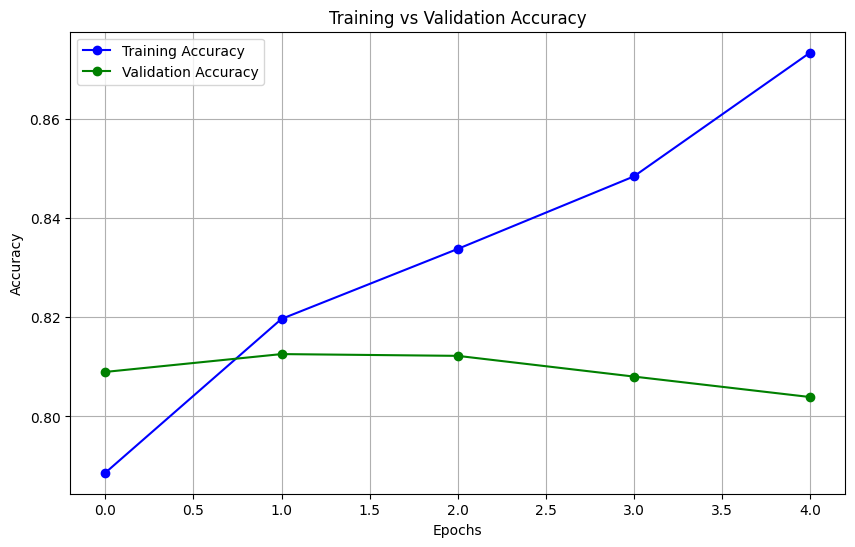

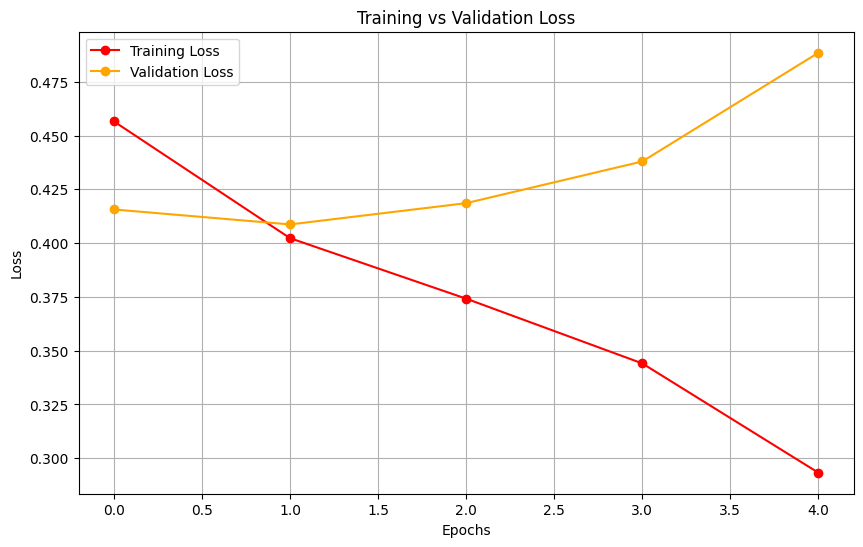

In [17]:
import matplotlib.pyplot as plt

# رسم الـ Accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# رسم الـ Loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='red', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### 📋 Detailed Classification Report (Training from Scratch)
### 📋 تقرير التصنيف المفصل (التدريب من الصفر)

> **English:** Generate test predictions and compute a comprehensive Scikit-Learn classification report detailing precision, recall, f1-score, and support metrics for each class.

> **العربية:** توليد التنبؤات على بيانات الاختبار وإنشاء تقرير تصنيف شامل باستخدام Scikit-Learn يوضح مقاييس الدقة والاسترجاع وF1-score لكل فئة.

In [18]:
from sklearn.metrics import classification_report

# التوقع على X_test
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

print("="*40)
print("       Classification Report")
print("="*40)
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)']))

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step
       Classification Report
              precision    recall  f1-score   support

Negative (0)       0.80      0.83      0.82     80000
Positive (1)       0.83      0.79      0.81     80000

    accuracy                           0.81    160000
   macro avg       0.81      0.81      0.81    160000
weighted avg       0.81      0.81      0.81    160000



### 🧩 Confusion Matrix Visualization (Training from Scratch)
### 🧩 مصفوفة الارتباك (التدريب من الصفر)

> **English:** Compute the confusion matrix and plot a professional Seaborn heatmap with customized labels to evaluate the binary sentiment classification results.

> **العربية:** حساب مصفوفة الارتباك ورسم خريطة حرارية احترافية باستخدام Seaborn مع تسميات مخصصة لتقييم نتائج نموذج التصنيف الثنائي.

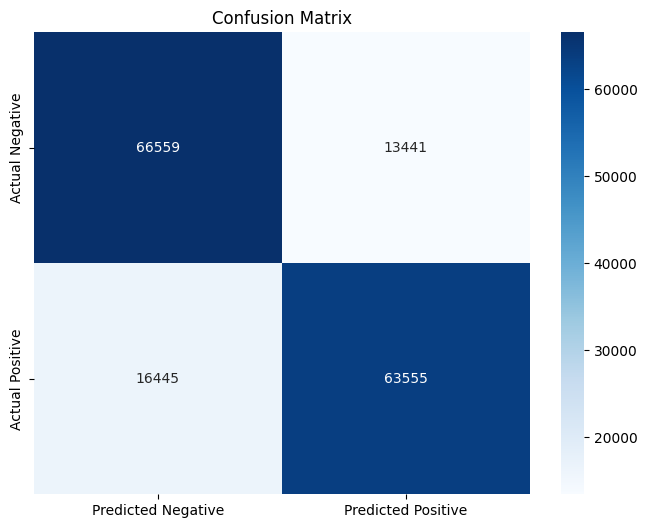

In [19]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix')
plt.show()

### 🔮 Model Inference & Prediction Pipeline (Training from Scratch)
### 🔮 مرحلة الاستدلال والتنبؤ للنصوص الجديدة (التدريب من الصفر)

> **English:** Define a robust inference function to preprocess, tokenize, pad, and predict sentiment polarity along with confidence scores for new text samples.

> **العربية:** تعريف دالة استدلال قوية لمعالجة، ترميز، حشو، والتنبؤ باتجاه المشاعر مع حساب درجات الثقة للنصوص الجديدة.

In [21]:
import numpy as np

def predict_sentiment(text):
    # 1. تنظيف النص (نفس الفانكشن اللي استخدمناها في الأول)
    cleaned_text = advanced_normalization(text)

    # 2. تحويل النص لأرقام باستخدام الـ tokenizer اللي دربناه
    sequence = tokenizer.texts_to_sequences([cleaned_text])

    # 3. توحيد الطول (Padding)
    padded_sequence = pad_sequences(sequence, maxlen=100, padding='pre', truncating='post')

    # 4. التوقع
    prediction = model.predict(padded_sequence)[0][0]

    # 5. عرض النتيجة
    sentiment = "Positive 😊" if prediction > 0.5 else "Negative 😠"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    print(f"Text: {text}")
    print(f"Sentiment: {sentiment} (Confidence: {confidence*100:.2f}%)")
    print("-" * 30)

# --- جرب الموديل هنا ---
predict_sentiment("I really love this new update, it is amazing!")
predict_sentiment("I hate waiting for so long, this is the worst service ever.")
predict_sentiment("The weather is okay, but the food was bad.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step
Text: I really love this new update, it is amazing!
Sentiment: Positive 😊 (Confidence: 98.70%)
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Text: I hate waiting for so long, this is the worst service ever.
Sentiment: Negative 😠 (Confidence: 98.26%)
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Text: The weather is okay, but the food was bad.
Sentiment: Negative 😠 (Confidence: 88.09%)
------------------------------


### 💾 Model Serialization & Export (Training from Scratch)
### 💾 حفظ وتصدير الموديل بصيغة حديثة (التدريب من الصفر)

> **English:** Save the trained neural network model weights and architecture into the modern native Keras format for future deployment and inference.

> **العربية:** حفظ أوزان وهيكل نموذج الشبكة العصبية المدرب بصيغة Keras الحديثة للاستخدام المستقبلي في النشر والاستدلال.

In [ ]:
# حفظ الموديل بأحدث صيغة
model.save('sentiment_model.keras')
print("Model saved successfully as sentiment_model.keras")